In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
sns.set(style="whitegrid")

In [12]:
df = pd.read_csv("ethiopia.csv")
df["Country"] = "Ethiopia"

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia


In [13]:
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month

In [14]:
df

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


In [15]:
df.replace(-999, np.nan, inplace=True)

##### replace missing values

In [16]:
df.duplicated().sum()

0

##### no duplicated values so we don't have to drop 


In [41]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


In [42]:
missing = df.isna().sum()
percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": percent
})

,Missing Values,Percentage
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


no missing values

In [43]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()

outliers

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64

code calculates Z-scores for key weather variables and counts how many extreme values (outliers) exist in each column.
The dataset contains no missing values. However, the Z-score analysis shows several outliers, particularly in precipitation 95 and minimum temperature 18, indicating natural climate variability and extreme weather events.

After replacing sentinel values (-999) with NaN, a check using df.isna().sum() showed that there are no missing values in the dataset. Therefore, no imputation or filling strategy was applied.

In [44]:
df.to_csv("ethiopia_clean.csv", index=False)

In [45]:
import os
os.makedirs("data", exist_ok=True)

In [46]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

OSError: Cannot save file into a non-existent directory: '..\data'

In [ ]:
import os

# Check if the file exists
if os.path.exists("ethiopia_clean.csv"):
    print("File successfully created!")
    # Show the first 5 lines of the actual file content
    with open("ethiopia_clean.csv", "r") as f:
        for _ in range(5):
            print(f.readline().strip())
else:
    print("File not found. Check your directory.")

File successfully created!
YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.0,Ethiopia,2015-01-01,1
2015,2,12.3,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2015,3,12.49,24.17,3.97,20.2,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
2015,4,14.08,23.78,6.9,16.88,0.0,38.84,0.87,1.28,77.07,4.6,Ethiopia,2015-01-04,1


Time Series Insights:
The temperature trend shows seasonal variation, with the warmest month occurring in month and the coolest in month.
Precipitation analysis indicates that peak rainfall occurs during months, suggesting a clear rainy season pattern.
Some anomalies may be observed in certain years, possibly indicating unusual climate events.

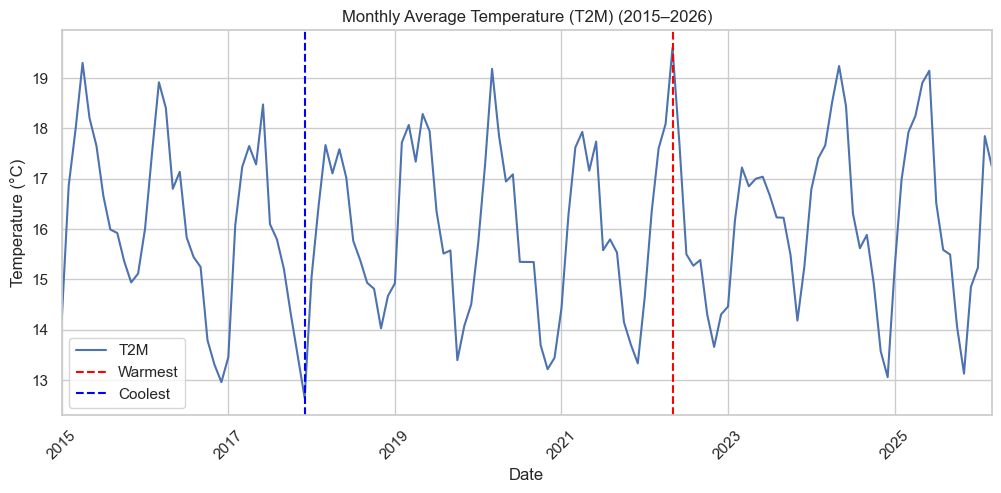

In [51]:
# Group by Year-Month for full timeline
df["YearMonth"] = df["Date"].dt.to_period("M")

monthly_temp = df.groupby("YearMonth")["T2M"].mean()

plt.figure(figsize=(12,5)) ##to create clear image i used large figure size
monthly_temp.plot()
plt.title("Monthly Average Temperature (T2M) (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)

# Find warmest & coolest months
warmest = monthly_temp.idxmax()
coolest = monthly_temp.idxmin()

plt.axvline(warmest.to_timestamp(), color='red', linestyle='--', label='Warmest')
plt.axvline(coolest.to_timestamp(), color='blue', linestyle='--', label='Coolest')

plt.legend()
plt.show()

The monthly average temperature (T2M) exhibits a clear and consistent seasonal cycle, with temperatures rising and falling at regular intervals each year. The warmest point occurs around 2022, while the coolest period is observed around 2017. Although there are year-to-year fluctuations, there is no strong long-term upward or downward trend, suggesting relatively stable temperature patterns over the 2015–2026 period.

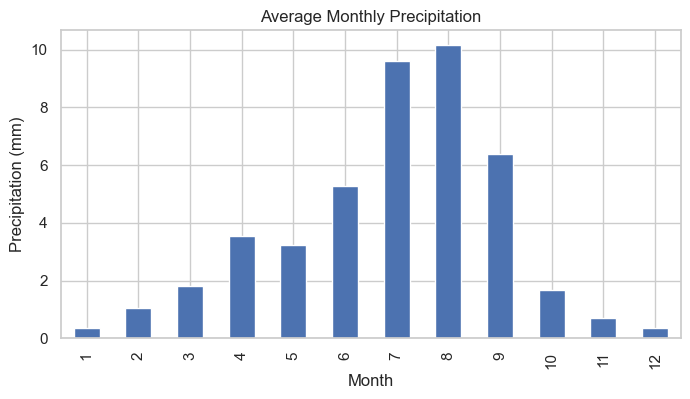

In [56]:
monthly_pattern = df.groupby("Month")["PRECTOTCORR"].mean()

monthly_pattern.plot(kind="bar", figsize=(8,4))
plt.title("Average Monthly Precipitation")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")
plt.show()

The chart shows a strong seasonal rainfall pattern, with precipitation increasing steadily from the beginning of the year and peaking in July and August, indicating the main rainy season. After August, rainfall declines sharply toward the end of the year, with very low precipitation from November to February, representing the dry season.

In [57]:
df

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,YearMonth
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1,2015-01
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1,2015-01
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1,2015-01
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1,2015-01
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1,2015-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3,2026-03
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3,2026-03
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3,2026-03
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3,2026-03


In [65]:
h=df.loc[df["PRECTOTCORR"]>10,'PRECTOTCORR']
h

125     16.47
144     29.07
145     34.38
172     14.32
174     17.52
        ...  
3916    11.91
3926    19.84
3927    23.84
4097    20.52
4098    15.32
Name: PRECTOTCORR, Length: 463, dtype: float64

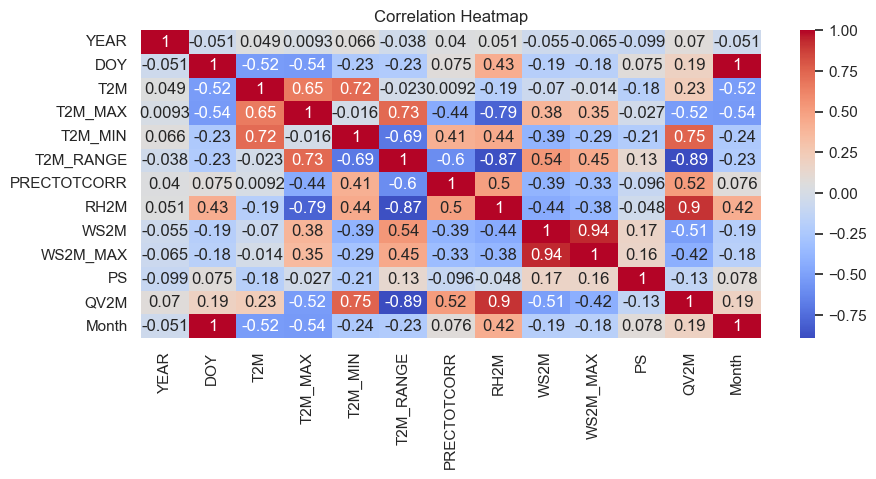

In [69]:
plt.figure(figsize=(10,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##### From the analysis, temperature-related variables show strong positive correlations among themselves. For example, average temperature (T2M) is highly correlated with both maximum temperature (T2M_MAX) and minimum temperature (T2M_MIN), indicating that these variables tend to increase and decrease together. Similarly, T2M_RANGE (the difference between maximum and minimum temperature) also shows noticeable relationships with these variables, though in some cases the correlation is negative, suggesting inverse behavior.
##### Rainfall (PRECTOTCORR) has a moderate positive relationship with relative humidity (RH2M), which is expected since higher humidity often leads to increased chances of precipitation. On the other hand, rainfall tends to have weaker or slightly negative correlations with temperature variables, suggesting that higher rainfall periods may be associated with cooler conditions.
##### Wind speed variables (WS2M and WS2M_MAX) show a very strong positive correlation with each other (0.94), indicating consistency between average and maximum wind speeds. These variables also show moderate relationships with some of the other factors, though not as strong as temperature or humidity relationships.
##### Additionally, specific humidity (QV2M) shows a strong positive correlation with relative humidity (RH2M) indicating 0.9, meaning that as moisture in the air increases, both measures tend to rise together. Atmospheric pressure (PS), however, shows generally weak correlations with most variables, indicating that it does not strongly influence or vary with the other factors in this dataset.
##### the heatmap reveals clear patterns in how climate variables interact. Temperature variables are closely linked, rainfall is influenced by humidity, and wind-related variables are strongly connected .


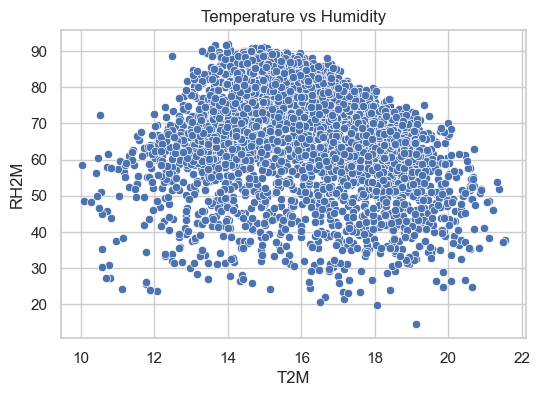

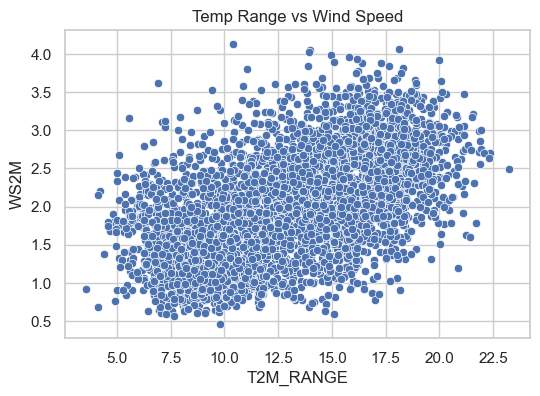

In [66]:
# T2M vs RH2M
plt.figure(figsize=(6,4))
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.title("Temperature vs Humidity")
plt.show()

# T2M_RANGE vs WS2M
plt.figure(figsize=(6,4))
sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.title("Temp Range vs Wind Speed")
plt.show()

###### Temperature vs Humidity (T2M vs RH2M)


##### Highest humidity values (around 80–90%) occur mostly at moderate temperatures (13–16°C).
##### At lower and higher temperatures, humidity tends to spread out and slightly decrease.
##### The relationship is non-linear and weak — temperature alone does not strongly predict humidity.


##### Temperature Range vs Wind Speed (T2M_RANGE vs WS2M)

##### The points show a clear upward trend.
##### As temperature range increases, wind speed also increases.
##### The spread is tighter compared to the first plot, indicating a moderate positive correlation.

##### Moderate positive relationship; larger daily temperature variations are associated with stronger winds.


##### The first plot shows weak/non-linear correlation.

##### The second plot shows a clearer and stronger linear relationship.

##### This suggests wind speed is more predictably linked to temperature variation than humidity is to temperature.

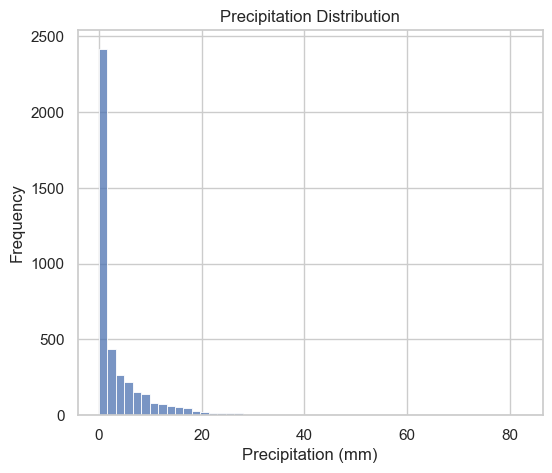

In [72]:
plt.figure(figsize=(6,5))
sns.histplot(df["PRECTOTCORR"], bins=50)

plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")

plt.show()

The distribution is positively skewed (right-skewed).

It is not symmetric and resembles a long-tailed distribution, typical of precipitation data where extreme events are infrequent but significant.

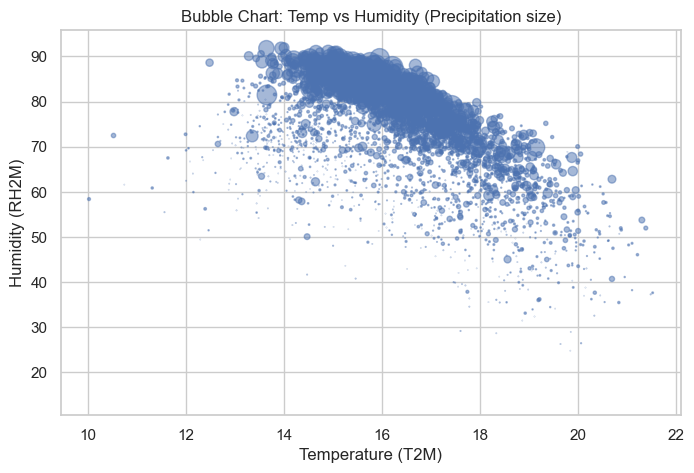

In [75]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 5,   # bubble size
    alpha=0.5
)

plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Bubble Chart: Temp vs Humidity (Precipitation size)")

plt.show()

chart reveals an inverse relationship between Mean Temperature (T2M) and Relative Humidity (RH2M), where higher humidity levels are concentrated at lower temperatures ($14°C$ to $16°C$). The larger bubbles indicate that peak Precipitation (PRECTOTCORR) events predominantly occur during these high-humidity, cooler periods, highlighting the seasonal nature of rainfall. The presence of high-temperature, low-humidity clusters ($>18°C$) points 